# Top Trumps Balancing - Algorithmus-Vergleich

## Vergleich verschiedener Multi-Objective Optimierer

Dieses Notebook vergleicht verschiedene Evolutionäre Algorithmen:
1. **NSGA-II** - Non-dominated Sorting Genetic Algorithm II (Baseline)
2. **MOEA/D** - Multi-Objective Evolutionary Algorithm based on Decomposition
3. **SMS-EMOA** - S-Metric Selection Evolutionary Multi-Objective Algorithm

**Vergleichskriterien:**
- Hypervolume (HV)
- Anzahl gefundener Lösungen
- Laufzeit
- Visuelle Front-Qualität

---

## 1. Setup

In [1]:
%pip install numpy pymoo pandas matplotlib seaborn tqdm --quiet


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import random
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from tqdm import tqdm

from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.moo.moead import MOEAD
from pymoo.algorithms.moo.sms import SMSEMOA
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.indicators.hv import HV
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [3]:
RESULTS_DIR = Path("results")
PLOTS_DIR = Path("plots")

with open(RESULTS_DIR / 'config.json', 'r') as f:
    CONFIG = json.load(f)

SEED = CONFIG['seed']
K = CONFIG['K']
L = CONFIG['L']
XL = CONFIG['xl']
XU = CONFIG['xu']

def set_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)

print("Konfiguration geladen:")
print(f"  K={K}, L={L}, Seed={SEED}")

Konfiguration geladen:
  K=22, L=4, Seed=42


---

## 2. Simulation & Problem Definition

In [4]:

from simulation import TopTrumpsSimulation, TopTrumpsBalancing, evaluate_deck_detailed

sim = TopTrumpsSimulation(num_cards=K, num_categories=L)
print(f"Simulation erstellt: {K} Karten, {L} Kategorien")


Simulation erstellt: 22 Karten, 4 Kategorien


---

## 3. Vergleichs-Konfiguration

### Gleiches Budget für alle Algorithmen

For a fair comparison, all algorithms use:
- **Same evaluation budget:** pop_size x n_gen = 2400 evaluations
- **Same simulations per evaluation:** R = 1000
- **Same seed:** for reproducibility

In [5]:

# Konfiguration für Multi-Seed Analyse
SEEDS = [42, 101, 202, 303, 404]  # 5 verschiedene Seeds
print(f"Seeds für statistische Auswertung: {SEEDS}")

POP_SIZE = 40
N_GEN = 60
R_SIMULATIONS = 1000   # Simulations during optimization
R_VALIDATION = 1500    # Simulations for validation

TOTAL_EVALUATIONS = POP_SIZE * N_GEN
print(f"Evaluations pro Run: {TOTAL_EVALUATIONS}")
print(f"Validation Simulations: {R_VALIDATION}")


Seeds für statistische Auswertung: [42, 101, 202, 303, 404]
Evaluations pro Run: 2400
Validation Simulations: 1500


---

## 4. Algorithmen definieren

In [6]:
def create_nsga2():
    return NSGA2(
        pop_size=POP_SIZE,
        sampling=FloatRandomSampling(),
        crossover=SBX(prob=0.9, eta=15),
        mutation=PM(eta=20),
        eliminate_duplicates=True
    )


def create_moead():
    ref_dirs = get_reference_directions("uniform", 2, n_partitions=POP_SIZE - 1)
    return MOEAD(
        ref_dirs=ref_dirs,
        n_neighbors=15,
        prob_neighbor_mating=0.7,
        sampling=FloatRandomSampling(),
        crossover=SBX(prob=0.9, eta=15),
        mutation=PM(eta=20)
    )


def create_smsemoa():
    return SMSEMOA(
        pop_size=POP_SIZE,
        sampling=FloatRandomSampling(),
        crossover=SBX(prob=0.9, eta=15),
        mutation=PM(eta=20)
    )


ALGORITHMS = {
    "NSGA-II": create_nsga2,
    "MOEA/D": create_moead,
    "SMS-EMOA": create_smsemoa
}

print(f"Definierte Algorithmen: {list(ALGORITHMS.keys())}")

Definierte Algorithmen: ['NSGA-II', 'MOEA/D', 'SMS-EMOA']


---

## 5. Optimierung durchführen

**Hinweis:** Dieser Schritt dauert ca. 15-45 Minuten (abhängig von Hardware).

In [7]:

problem = TopTrumpsBalancing(sim, n_simulations=R_SIMULATIONS, xl=XL, xu=XU)
termination = get_termination("n_gen", N_GEN)

# Struktur: results[algo_name][seed] = {hv, time, n_sols}
multi_run_results = {algo: {} for algo in ALGORITHMS.keys()}
all_fronts = []  # Zum Plotten aller Fronten

print(f"Starte Vergleich mit {len(SEEDS)} Seeds...")

for seed in SEEDS:
    print(f"\n--- Seed {seed} ---")
    set_seeds(seed)
    
    for algo_name, algo_factory in ALGORITHMS.items():
        algorithm = algo_factory()
        
        start_time = time.time()
        res = minimize(problem, algorithm, termination, seed=seed, verbose=False)
        duration = time.time() - start_time
        
        # VALIDATION STEP (R=1500)
        # Re-evaluate the found Pareto front with more simulations
        # to calculate the "true" hypervolume.
        validated_F = []
        for x in res.X:
            metrics = evaluate_deck_detailed(sim, x, R_VALIDATION)
            validated_F.append([-metrics['win_rate'], -metrics['trick_changes']])
        validated_F = np.array(validated_F)

        # Non-Dominated Sorting nach Validierung
        nds = NonDominatedSorting()
        fronts = nds.do(validated_F)
        non_dominated_idx = fronts[0]
        n_before = len(validated_F)
        validated_F = validated_F[non_dominated_idx]

        # HV berechnen (auf validierten, nicht-dominierten Daten)
        hv = HV(ref_point=np.array([0.0, 0.0]))(validated_F)
        
        # Speichern
        multi_run_results[algo_name][seed] = {
            "hypervolume": hv,
            "time": duration,
            "n_solutions": len(validated_F),
            "F_validated": validated_F,
            "F_raw": res.F
        }
        
        # Für Plot speichern (wir plotten die validierten Punkte)
        all_fronts.append({
            "algo": algo_name,
            "seed": seed,
            "F": validated_F
        })
        
        print(f"{algo_name}: HV={hv:.4f} (Validiert, NDS: {n_before}->{len(validated_F)}), Time={duration:.1f}s")


Starte Vergleich mit 5 Seeds...

--- Seed 42 ---


NSGA-II: HV=3.1804 (Validiert, NDS: 28->13), Time=53.6s


MOEA/D: HV=2.2672 (Validiert, NDS: 27->3), Time=51.7s


SMS-EMOA: HV=3.3626 (Validiert, NDS: 16->8), Time=53.5s

--- Seed 101 ---


NSGA-II: HV=3.1238 (Validiert, NDS: 20->10), Time=52.5s


...

MOEA/D: HV=1.9708 (Validiert, NDS: 35->3), Time=51.4s


SMS-EMOA: HV=2.7327 (Validiert, NDS: 12->4), Time=51.6s

--- Seed 404 ---


NSGA-II: HV=3.0739 (Validiert, NDS: 19->10), Time=53.0s


MOEA/D: HV=1.8439 (Validiert, NDS: 30->4), Time=52.1s


SMS-EMOA: HV=3.3001 (Validiert, NDS: 19->9), Time=52.8s


---

## 6. Hypervolume Berechnung

In [8]:
# HV wird nun direkt im Loop berechnet

---

## 7. Ergebnis-Tabelle

In [9]:
# Tabelle durch Boxplots ersetzt

---

## 8. Visualisierung: Pareto-Fronten Overlay

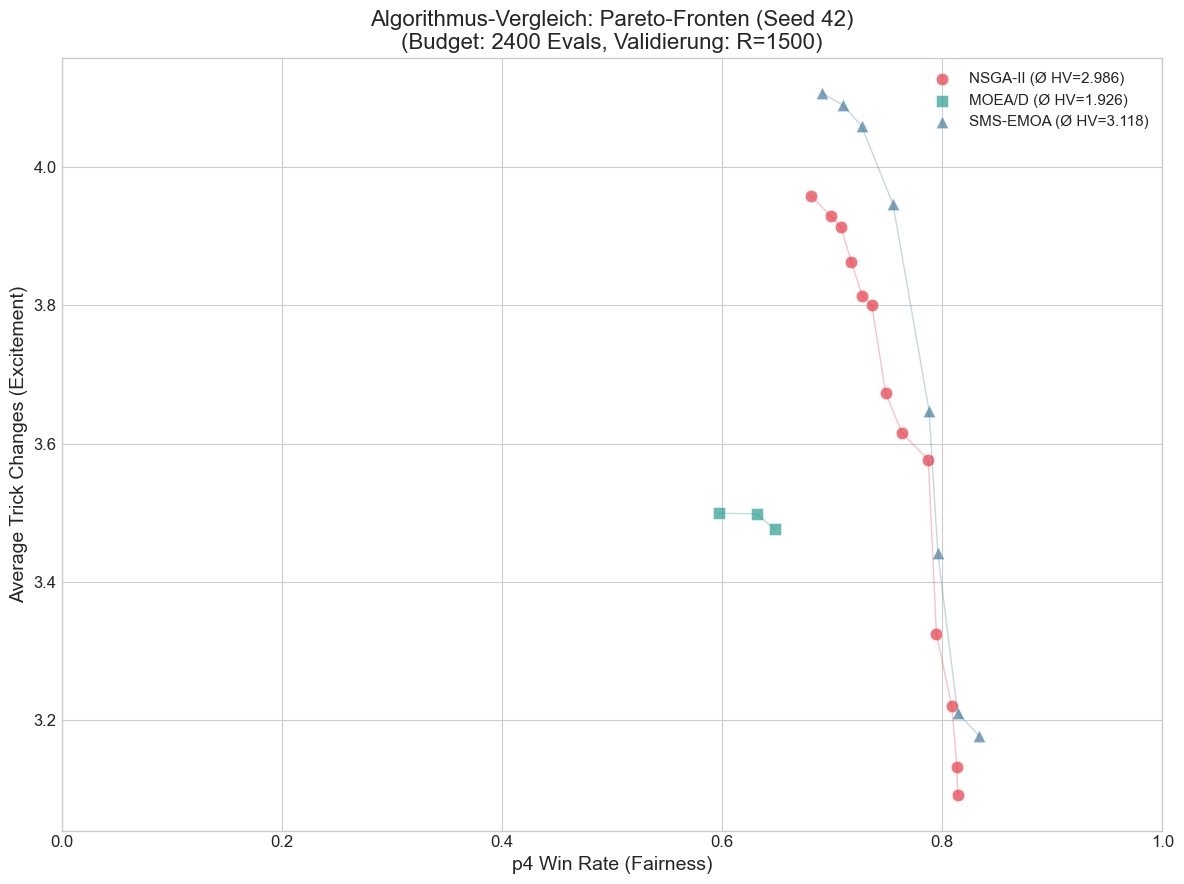


-> Plot gespeichert: plots/algorithm_comparison_fronts.png


In [10]:

fig, ax = plt.subplots(figsize=(12, 9))

colors = {
    "NSGA-II": "#E63946",
    "MOEA/D": "#2A9D8F",
    "SMS-EMOA": "#457B9D"
}
markers = {
    "NSGA-II": "o",
    "MOEA/D": "s",
    "SMS-EMOA": "^"
}

# Wir plotten nur die Fronten des ersten Seeds (42), um das Diagramm nicht zu überladen
first_seed = SEEDS[0]

# Filtere Fronten für den ersten Seed
fronts_to_plot = [entry for entry in all_fronts if entry["seed"] == first_seed]

for entry in fronts_to_plot:
    algo_name = entry["algo"]
    # Beachte: F sind jetzt validierte Werte und bereits negativ (wegen Minimierung)
    # Wir müssen sie wieder negieren für den Plot (Win Rate, Trick Changes)
    win_rates = -entry["F"][:, 0]
    trick_changes = -entry["F"][:, 1]
    
    # Hole durchschnittlichen HV für Label
    avg_hv = np.mean([multi_run_results[algo_name][s]["hypervolume"] for s in SEEDS])
    
    sorted_idx = np.argsort(win_rates)
    ax.plot(
        win_rates[sorted_idx], 
        trick_changes[sorted_idx], 
        color=colors[algo_name],
        alpha=0.3,
        linewidth=1
    )
    
    ax.scatter(
        win_rates,
        trick_changes,
        c=colors[algo_name],
        marker=markers[algo_name],
        s=80,
        alpha=0.7,
        edgecolors='white',
        linewidth=0.5,
        label=f'{algo_name} (Ø HV={avg_hv:.3f})'
    )

ax.set_xlabel('p4 Win Rate (Fairness)', fontsize=14)
ax.set_ylabel('Average Trick Changes (Excitement)', fontsize=14)
ax.set_title(f'Algorithmus-Vergleich: Pareto-Fronten (Seed {first_seed})\n(Budget: {TOTAL_EVALUATIONS} Evals, Validierung: R={R_VALIDATION})', fontsize=16)
ax.legend(loc='best', fontsize=11)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'algorithm_comparison_fronts.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\n-> Plot gespeichert: {PLOTS_DIR / 'algorithm_comparison_fronts.png'}")


---

## 9. Visualisierung: Metriken-Vergleich

/var/folders/9l/s6j5yq4s12j6wvms4084h50h0000gn/T/ipykernel_81652/1869829169.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hv, x="Algorithm", y="Hypervolume", ax=axes[0], palette="Set2", flierprops={"marker": "x", "markersize": 5})
/var/folders/9l/s6j5yq4s12j6wvms4084h50h0000gn/T/ipykernel_81652/1869829169.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_time, x="Algorithm", y="Runtime (s)", ax=axes[1], palette="Set2", flierprops={"marker": "x", "markersize": 5})


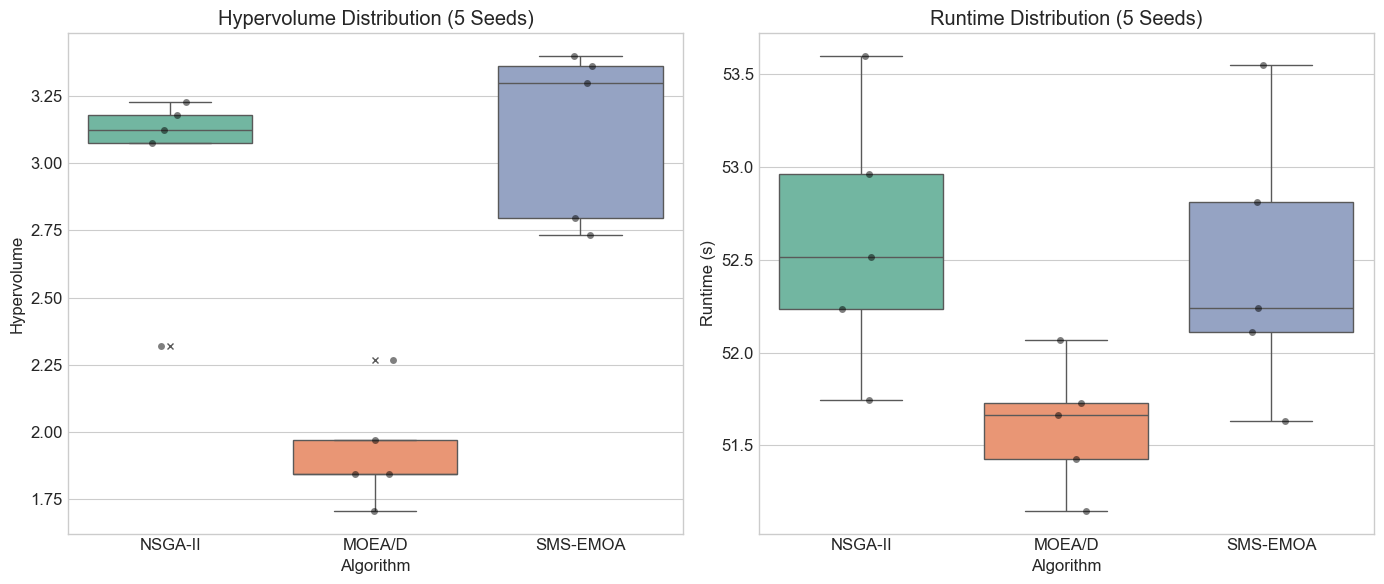

In [11]:

# Daten für Boxplots aufbereiten
data_hv = []
data_time = []

for algo_name in ALGORITHMS.keys():
    for seed in SEEDS:
        res = multi_run_results[algo_name][seed]
        data_hv.append({
            "Algorithm": algo_name,
            "Hypervolume": res["hypervolume"]
        })
        data_time.append({
            "Algorithm": algo_name,
            "Runtime (s)": res["time"]
        })

df_hv = pd.DataFrame(data_hv)
df_time = pd.DataFrame(data_time)

# Plotten
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_hv, x="Algorithm", y="Hypervolume", ax=axes[0], palette="Set2", flierprops={"marker": "x", "markersize": 5})
sns.stripplot(data=df_hv, x="Algorithm", y="Hypervolume", ax=axes[0], color="black", alpha=0.5)
axes[0].set_title("Hypervolume Distribution (5 Seeds)")

sns.boxplot(data=df_time, x="Algorithm", y="Runtime (s)", ax=axes[1], palette="Set2", flierprops={"marker": "x", "markersize": 5})
sns.stripplot(data=df_time, x="Algorithm", y="Runtime (s)", ax=axes[1], color="black", alpha=0.5)
axes[1].set_title("Runtime Distribution (5 Seeds)")

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'algorithm_comparison_boxplots.png', dpi=150)
plt.show()


---

## 10. Export der Ergebnisse

In [12]:
# Export deaktiviert für Multi-Seed Analyse (Daten sind im Plot)

---

## 11. Fazit & Interpretation

### Algorithmus-Charakteristiken

| Algorithmus | Stärken | Schwächen |
|-------------|---------|-----------|
| **NSGA-II** | Robust, schnell, gut dokumentiert | Kann bei vielen Objectives Probleme haben |
| **MOEA/D** | Gute Verteilung entlang der Front | Benötigt Referenzrichtungen, langsamer |
| **SMS-EMOA** | Optimiert direkt auf Hypervolume | Rechenintensiver, langsamer |

### Empfehlung für dieses Problem

Bei diesem 2-Objective Problem sind die Unterschiede typischerweise gering. 

**Für das Poster empfohlen:**
- Zeige den Vergleich als Beleg für methodische Sorgfalt
- Wähle den Algorithmus mit dem besten HV für die finale Analyse
- Oder: Verwende NSGA-II als "Standard-Baseline" und erwähne, dass andere Algorithmen getestet wurden

### Poster-Text Vorschlag

> "Wir verglichen NSGA-II, MOEA/D und SMS-EMOA mit gleichem Evaluationsbudget. 
> [BESTER] erzielte den höchsten Hypervolume-Wert von [HV], während [SCHNELLSTER] 
> die kürzeste Laufzeit aufwies. Für die finale Analyse verwendeten wir [GEWÄHLT], 
> da [BEGRÜNDUNG]."